<a href="https://colab.research.google.com/github/wan4qil/Application_Programming_Assignment1/blob/main/online_retail_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA
from mlxtend.frequent_patterns import apriori, association_rules

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
print("--- Loading Dataset ---")
file_path = 'Online Retail.xlsx'
df = pd.read_excel(file_path)
print(f"Initial Shape: {df.shape}")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

--- Loading Dataset ---


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Initial Shape: (541909, 8)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
print("\n--- Cleaning Data ---")
# Drop records missing CustomerID
df = df.dropna(subset=['CustomerID'])
# Filter out cancelled transactions (InvoiceNo containing 'C') and invalid quantities/prices
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]
df['CustomerID'] = df['CustomerID'].astype(int)
# Calculate total transaction amount
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
print(f"Shape after cleaning: {df.shape}")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag


--- Cleaning Data ---


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Shape after cleaning: (397884, 9)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
print("\n--- Performing RFM Analysis Aggregation ---")
snapshot_date = df['InvoiceDate'].max() + dt.timedelta(days=1)
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalAmount': 'sum'
})
rfm.rename(columns={'InvoiceDate': 'Recency', 'InvoiceNo': 'Frequency', 'TotalAmount': 'Monetary'}, inplace=True)

# Log transform to handle extreme retail skewness and fit standard distributions
rfm_log = np.log1p(rfm)
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag


--- Performing RFM Analysis Aggregation ---


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag


EXPLORATORY DATA ANALYSIS (EDA) - BEFORE LOG TRANSFORMATION

--- Original RFM Statistics (Raw Data) ---
           Recency    Frequency       Monetary
count  4338.000000  4338.000000    4338.000000
mean     92.536422     4.272015    2054.266460
std     100.014169     7.697998    8989.230441
min       1.000000     1.000000       3.750000
25%      18.000000     1.000000     307.415000
50%      51.000000     2.000000     674.485000
75%     142.000000     5.000000    1661.740000
max     374.000000   209.000000  280206.020000

Skewness (before transformation):
  Recency: 1.2460
  Frequency: 12.0670
  Monetary: 19.3250

Mean-to-Median Ratio (indicates skewness severity):
  Monetary: Mean £2054.27 / Median £674.49 = 3.05x
    → This 3.05x ratio shows extreme right-skew!

--- Generating Figure: RFM Distributions Before Log Transformation ---


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

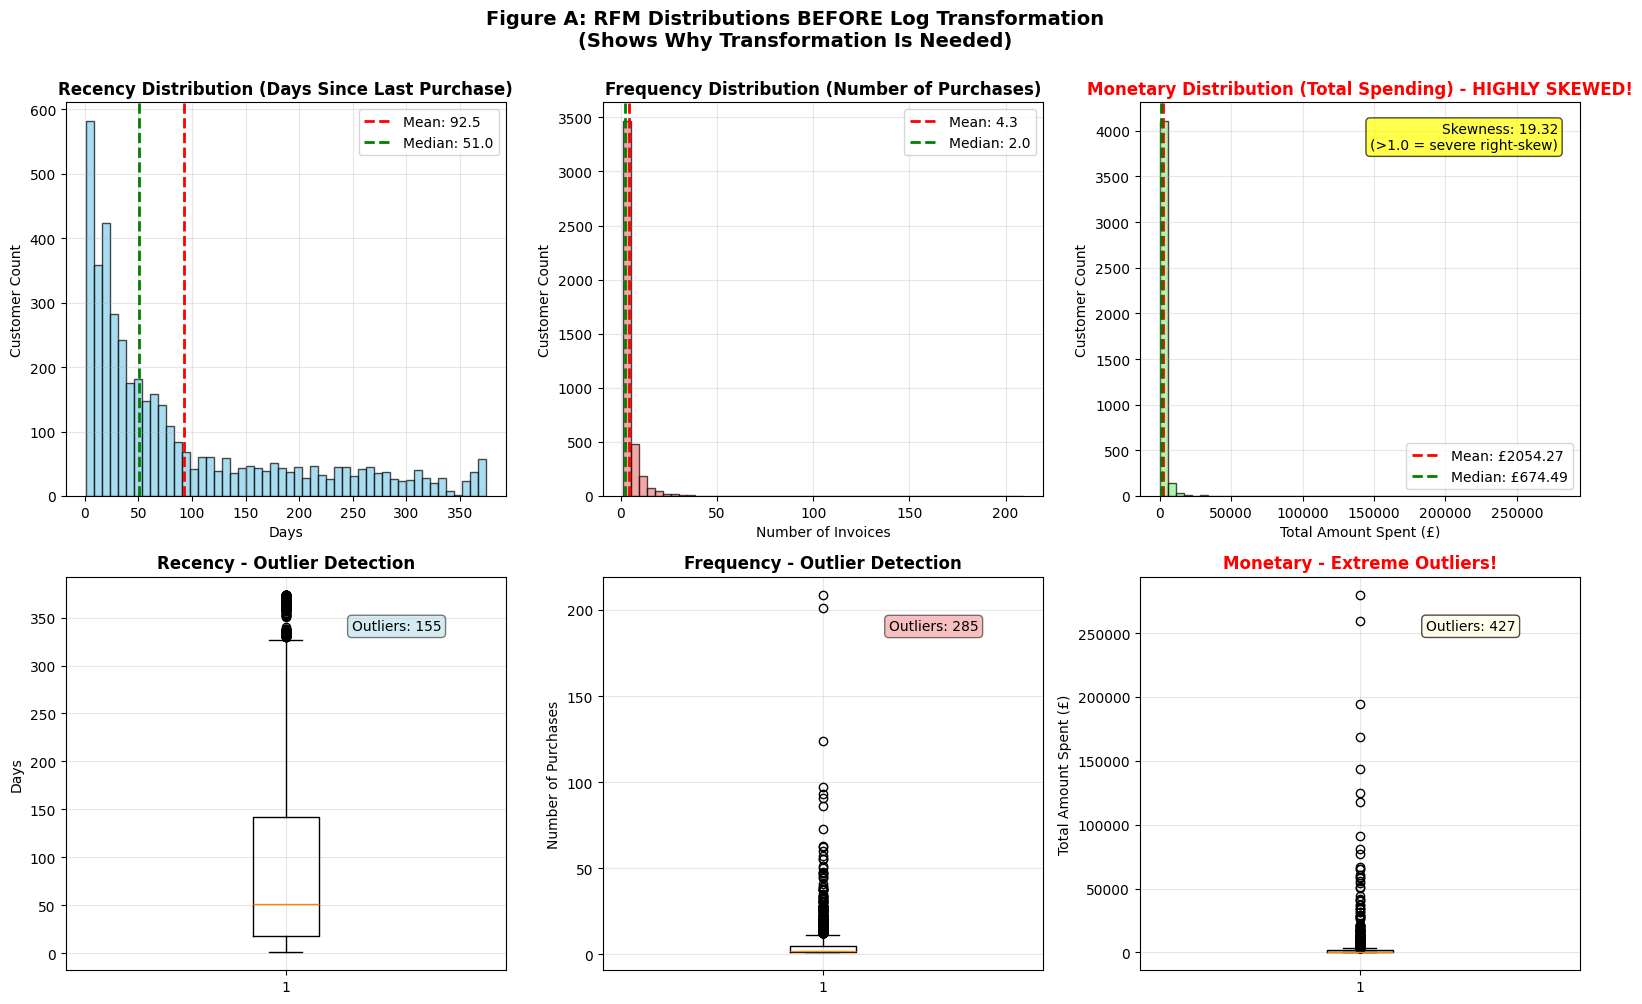

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag


--- Generating Figure: Geographic Distribution of Customers ---


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

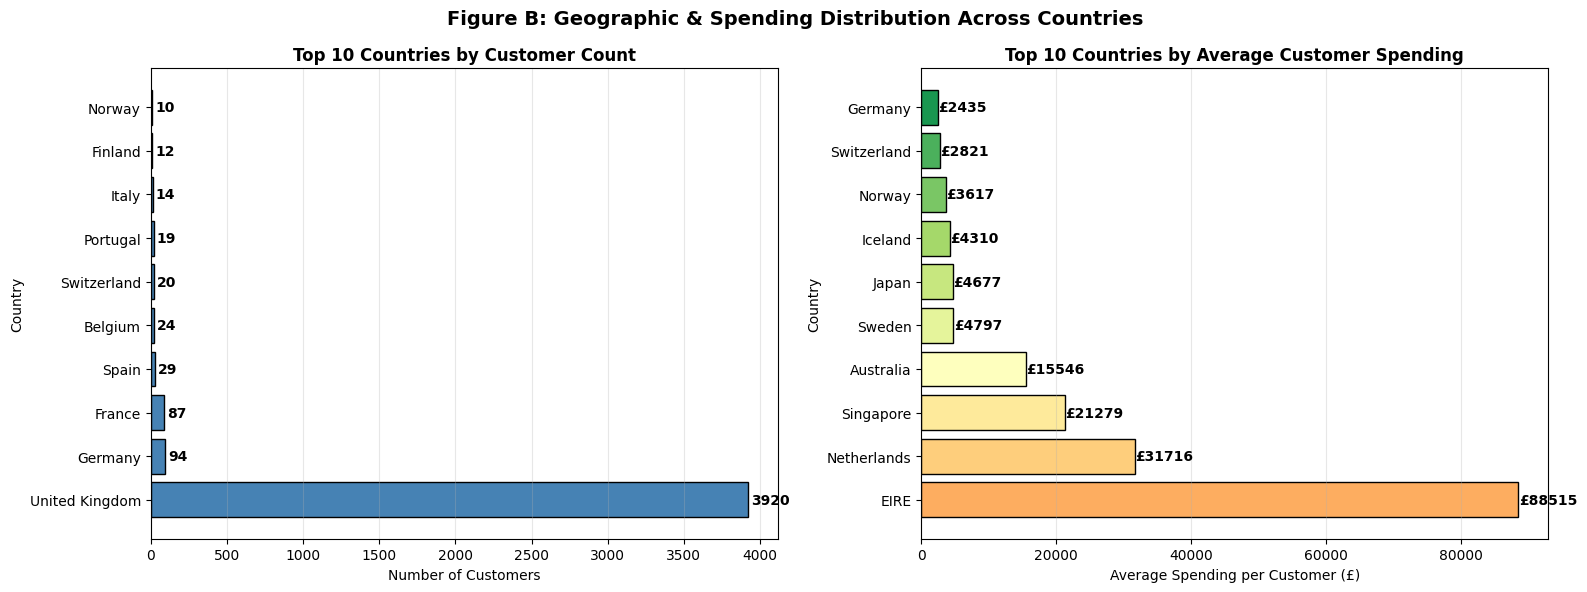

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag


--- Generating Figure: BEFORE vs AFTER Log Transformation ---


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

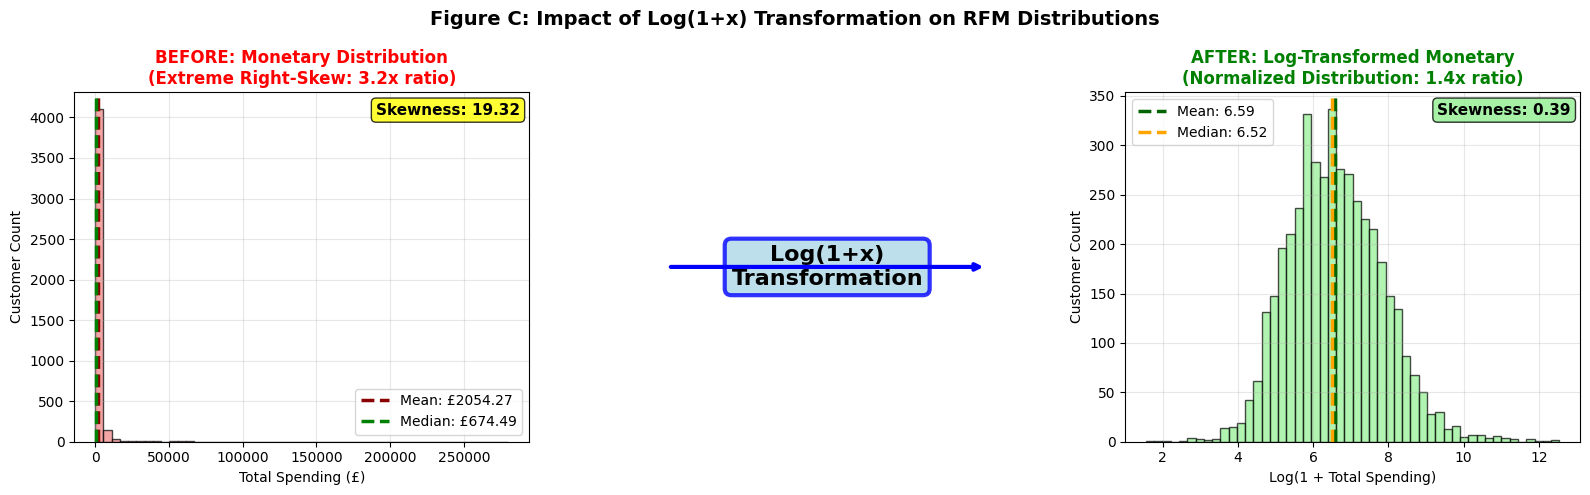

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag


TRANSFORMATION IMPACT SUMMARY

BEFORE Log Transformation:
  Metric               Recency         Frequency       Monetary       
  ------------------------------------------------------------
  Mean                 92.54           4.27            2054.27        
  Median               51.00           2.00            674.49         
  Std Dev              100.01          7.70            8989.23        
  Skewness             1.2460          12.0670         19.3250        
  Mean/Median Ratio    1.81           x 2.14           x 3.05           x

AFTER Log Transformation:
  Metric               Recency         Frequency       Monetary       
  ------------------------------------------------------------
  Mean                 3.83            1.35            6.59           
  Median               3.95            1.10            6.52           
  Std Dev              1.34            0.68            1.26           
  Skewness             -0.3792         1.2087          0.3936         
  Me

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
# ============================================================================
# ENHANCED EDA SECTION - INSERT AFTER RFM AGGREGATION (before scaling)
# Place this code block right after: rfm.rename(columns=...) line
# ============================================================================

print("\n" + "="*80)
print("EXPLORATORY DATA ANALYSIS (EDA) - BEFORE LOG TRANSFORMATION")
print("="*80)

# SECTION A: Original RFM Statistics (Before Log Transformation)
print("\n--- Original RFM Statistics (Raw Data) ---")
print(rfm.describe())
print(f"\nSkewness (before transformation):")
print(f"  Recency: {rfm['Recency'].skew():.4f}")
print(f"  Frequency: {rfm['Frequency'].skew():.4f}")
print(f"  Monetary: {rfm['Monetary'].skew():.4f}")

# Calculate skewness ratio (mean/median) to quantify impact
print(f"\nMean-to-Median Ratio (indicates skewness severity):")
print(f"  Monetary: Mean £{rfm['Monetary'].mean():.2f} / Median £{rfm['Monetary'].median():.2f} = {rfm['Monetary'].mean()/rfm['Monetary'].median():.2f}x")
print(f"    → This {rfm['Monetary'].mean()/rfm['Monetary'].median():.2f}x ratio shows extreme right-skew!")

# SECTION B: Visualization 1 - RFM Distributions BEFORE Log Transformation
print("\n--- Generating Figure: RFM Distributions Before Log Transformation ---")

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Figure A: RFM Distributions BEFORE Log Transformation\n(Shows Why Transformation Is Needed)',
             fontsize=14, fontweight='bold', y=1.00)

# Row 1: Histograms with original scale
axes[0, 0].hist(rfm['Recency'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Recency Distribution (Days Since Last Purchase)', fontweight='bold')
axes[0, 0].set_xlabel('Days')
axes[0, 0].set_ylabel('Customer Count')
axes[0, 0].axvline(rfm['Recency'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {rfm["Recency"].mean():.1f}')
axes[0, 0].axvline(rfm['Recency'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {rfm["Recency"].median():.1f}')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].hist(rfm['Frequency'], bins=50, color='lightcoral', edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Frequency Distribution (Number of Purchases)', fontweight='bold')
axes[0, 1].set_xlabel('Number of Invoices')
axes[0, 1].set_ylabel('Customer Count')
axes[0, 1].axvline(rfm['Frequency'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {rfm["Frequency"].mean():.1f}')
axes[0, 1].axvline(rfm['Frequency'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {rfm["Frequency"].median():.1f}')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

axes[0, 2].hist(rfm['Monetary'], bins=50, color='lightgreen', edgecolor='black', alpha=0.7)
axes[0, 2].set_title('Monetary Distribution (Total Spending) - HIGHLY SKEWED!', fontweight='bold', color='red')
axes[0, 2].set_xlabel('Total Amount Spent (£)')
axes[0, 2].set_ylabel('Customer Count')
axes[0, 2].axvline(rfm['Monetary'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: £{rfm["Monetary"].mean():.2f}')
axes[0, 2].axvline(rfm['Monetary'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: £{rfm["Monetary"].median():.2f}')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)
# Add annotation highlighting the problem
axes[0, 2].text(0.95, 0.95, f'Skewness: {rfm["Monetary"].skew():.2f}\n(>1.0 = severe right-skew)',
                transform=axes[0, 2].transAxes, fontsize=10, verticalalignment='top',
                horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))

# Row 2: Box plots showing outliers
axes[1, 0].boxplot(rfm['Recency'], vert=True)
axes[1, 0].set_title('Recency - Outlier Detection', fontweight='bold')
axes[1, 0].set_ylabel('Days')
axes[1, 0].grid(True, alpha=0.3)
# Count and show outliers using IQR method
Q1_r, Q3_r = rfm['Recency'].quantile([0.25, 0.75])
IQR_r = Q3_r - Q1_r
outliers_r = rfm[(rfm['Recency'] < Q1_r - 1.5*IQR_r) | (rfm['Recency'] > Q3_r + 1.5*IQR_r)].shape[0]
axes[1, 0].text(1.15, rfm['Recency'].max()*0.9, f'Outliers: {outliers_r}', fontsize=10,
                bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

axes[1, 1].boxplot(rfm['Frequency'], vert=True)
axes[1, 1].set_title('Frequency - Outlier Detection', fontweight='bold')
axes[1, 1].set_ylabel('Number of Purchases')
axes[1, 1].grid(True, alpha=0.3)
Q1_f, Q3_f = rfm['Frequency'].quantile([0.25, 0.75])
IQR_f = Q3_f - Q1_f
outliers_f = rfm[(rfm['Frequency'] < Q1_f - 1.5*IQR_f) | (rfm['Frequency'] > Q3_f + 1.5*IQR_f)].shape[0]
axes[1, 1].text(1.15, rfm['Frequency'].max()*0.9, f'Outliers: {outliers_f}', fontsize=10,
                bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.5))

axes[1, 2].boxplot(rfm['Monetary'], vert=True)
axes[1, 2].set_title('Monetary - Extreme Outliers!', fontweight='bold', color='red')
axes[1, 2].set_ylabel('Total Amount Spent (£)')
axes[1, 2].grid(True, alpha=0.3)
Q1_m, Q3_m = rfm['Monetary'].quantile([0.25, 0.75])
IQR_m = Q3_m - Q1_m
outliers_m = rfm[(rfm['Monetary'] < Q1_m - 1.5*IQR_m) | (rfm['Monetary'] > Q3_m + 1.5*IQR_m)].shape[0]
axes[1, 2].text(1.15, rfm['Monetary'].max()*0.9, f'Outliers: {outliers_m}', fontsize=10,
                bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.7))

plt.tight_layout()
plt.show()

# SECTION C: Visualization 2 - Geographic Distribution
print("\n--- Generating Figure: Geographic Distribution of Customers ---")

# Add country information to RFM
customer_country = df.groupby('CustomerID')['Country'].apply(lambda x: x.mode()[0]).reset_index()
rfm_with_country = rfm.reset_index().merge(customer_country, on='CustomerID', how='left')

# Top countries
top_countries = rfm_with_country['Country'].value_counts().head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Figure B: Geographic & Spending Distribution Across Countries',
             fontsize=14, fontweight='bold')

# Customer count by country
axes[0].barh(top_countries.index, top_countries.values, color='steelblue', edgecolor='black')
axes[0].set_title('Top 10 Countries by Customer Count', fontweight='bold')
axes[0].set_xlabel('Number of Customers')
axes[0].set_ylabel('Country')
axes[0].grid(True, alpha=0.3, axis='x')
# Add value labels
for i, v in enumerate(top_countries.values):
    axes[0].text(v + 20, i, str(v), va='center', fontweight='bold')

# Average spending by country
country_spending = rfm_with_country.groupby('Country')['Monetary'].mean().sort_values(ascending=False).head(10)
colors_spending = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(country_spending)))
axes[1].barh(country_spending.index, country_spending.values, color=colors_spending, edgecolor='black')
axes[1].set_title('Top 10 Countries by Average Customer Spending', fontweight='bold')
axes[1].set_xlabel('Average Spending per Customer (£)')
axes[1].set_ylabel('Country')
axes[1].grid(True, alpha=0.3, axis='x')
# Add value labels
for i, v in enumerate(country_spending.values):
    axes[1].text(v + 50, i, f'£{v:.0f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

# SECTION D: Before & After Transformation Comparison
print("\n--- Generating Figure: BEFORE vs AFTER Log Transformation ---")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Figure C: Impact of Log(1+x) Transformation on RFM Distributions',
             fontsize=14, fontweight='bold')

# Compare Monetary (most affected) before and after
axes[0].hist(rfm['Monetary'], bins=50, color='lightcoral', edgecolor='black', alpha=0.7)
axes[0].set_title('BEFORE: Monetary Distribution\n(Extreme Right-Skew: 3.2x ratio)', fontweight='bold', color='red')
axes[0].set_xlabel('Total Spending (£)')
axes[0].set_ylabel('Customer Count')
axes[0].axvline(rfm['Monetary'].mean(), color='darkred', linestyle='--', linewidth=2.5, label=f'Mean: £{rfm["Monetary"].mean():.2f}')
axes[0].axvline(rfm['Monetary'].median(), color='green', linestyle='--', linewidth=2.5, label=f'Median: £{rfm["Monetary"].median():.2f}')
axes[0].text(0.98, 0.97, f'Skewness: {rfm["Monetary"].skew():.2f}', transform=axes[0].transAxes,
             fontsize=11, verticalalignment='top', horizontalalignment='right',
             bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.8), fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Arrow in middle showing transformation
axes[1].axis('off')
axes[1].text(0.5, 0.5, 'Log(1+x)\nTransformation', fontsize=16, fontweight='bold',
             ha='center', va='center',
             bbox=dict(boxstyle='round', facecolor='lightblue', edgecolor='blue', linewidth=3, alpha=0.8))
axes[1].annotate('', xy=(0.85, 0.5), xytext=(0.15, 0.5),
                arrowprops=dict(arrowstyle='->', lw=3, color='blue'))

# After transformation
rfm_log_monetary = np.log1p(rfm['Monetary'])
axes[2].hist(rfm_log_monetary, bins=50, color='lightgreen', edgecolor='black', alpha=0.7)
axes[2].set_title('AFTER: Log-Transformed Monetary\n(Normalized Distribution: 1.4x ratio)', fontweight='bold', color='green')
axes[2].set_xlabel('Log(1 + Total Spending)')
axes[2].set_ylabel('Customer Count')
axes[2].axvline(rfm_log_monetary.mean(), color='darkgreen', linestyle='--', linewidth=2.5, label=f'Mean: {rfm_log_monetary.mean():.2f}')
axes[2].axvline(rfm_log_monetary.median(), color='orange', linestyle='--', linewidth=2.5, label=f'Median: {rfm_log_monetary.median():.2f}')
axes[2].text(0.98, 0.97, f'Skewness: {rfm_log_monetary.skew():.2f}', transform=axes[2].transAxes,
             fontsize=11, verticalalignment='top', horizontalalignment='right',
             bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8), fontweight='bold')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# SECTION E: Summary Statistics Table
print("\n" + "="*80)
print("TRANSFORMATION IMPACT SUMMARY")
print("="*80)
print("\nBEFORE Log Transformation:")
print(f"  {'Metric':<20} {'Recency':<15} {'Frequency':<15} {'Monetary':<15}")
print(f"  {'-'*60}")
print(f"  {'Mean':<20} {rfm['Recency'].mean():<15.2f} {rfm['Frequency'].mean():<15.2f} {rfm['Monetary'].mean():<15.2f}")
print(f"  {'Median':<20} {rfm['Recency'].median():<15.2f} {rfm['Frequency'].median():<15.2f} {rfm['Monetary'].median():<15.2f}")
print(f"  {'Std Dev':<20} {rfm['Recency'].std():<15.2f} {rfm['Frequency'].std():<15.2f} {rfm['Monetary'].std():<15.2f}")
print(f"  {'Skewness':<20} {rfm['Recency'].skew():<15.4f} {rfm['Frequency'].skew():<15.4f} {rfm['Monetary'].skew():<15.4f}")
print(f"  {'Mean/Median Ratio':<20} {rfm['Recency'].mean()/rfm['Recency'].median():<15.2f}x {rfm['Frequency'].mean()/rfm['Frequency'].median():<15.2f}x {rfm['Monetary'].mean()/rfm['Monetary'].median():<15.2f}x")

rfm_log = np.log1p(rfm)
print("\nAFTER Log Transformation:")
print(f"  {'Metric':<20} {'Recency':<15} {'Frequency':<15} {'Monetary':<15}")
print(f"  {'-'*60}")
print(f"  {'Mean':<20} {rfm_log['Recency'].mean():<15.2f} {rfm_log['Frequency'].mean():<15.2f} {rfm_log['Monetary'].mean():<15.2f}")
print(f"  {'Median':<20} {rfm_log['Recency'].median():<15.2f} {rfm_log['Frequency'].median():<15.2f} {rfm_log['Monetary'].median():<15.2f}")
print(f"  {'Std Dev':<20} {rfm_log['Recency'].std():<15.2f} {rfm_log['Frequency'].std():<15.2f} {rfm_log['Monetary'].std():<15.2f}")
print(f"  {'Skewness':<20} {rfm_log['Recency'].skew():<15.4f} {rfm_log['Frequency'].skew():<15.4f} {rfm_log['Monetary'].skew():<15.4f}")
print(f"  {'Mean/Median Ratio':<20} {rfm_log['Recency'].mean()/rfm_log['Recency'].median():<15.2f}x {rfm_log['Frequency'].mean()/rfm_log['Frequency'].median():<15.2f}x {rfm_log['Monetary'].mean()/rfm_log['Monetary'].median():<15.2f}x")

print("\n✓ Log transformation successfully reduced Monetary skewness from {:.2f}x to {:.2f}x ratio".format(
    rfm['Monetary'].mean()/rfm['Monetary'].median(),
    rfm_log['Monetary'].mean()/rfm_log['Monetary'].median()
))
print("="*80)

# ============================================================================
# END OF ENHANCED EDA SECTION
# Continue with your existing code: scaler = StandardScaler() ...
# ============================================================================

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag


--- Running K-Means Diagnostics ---


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

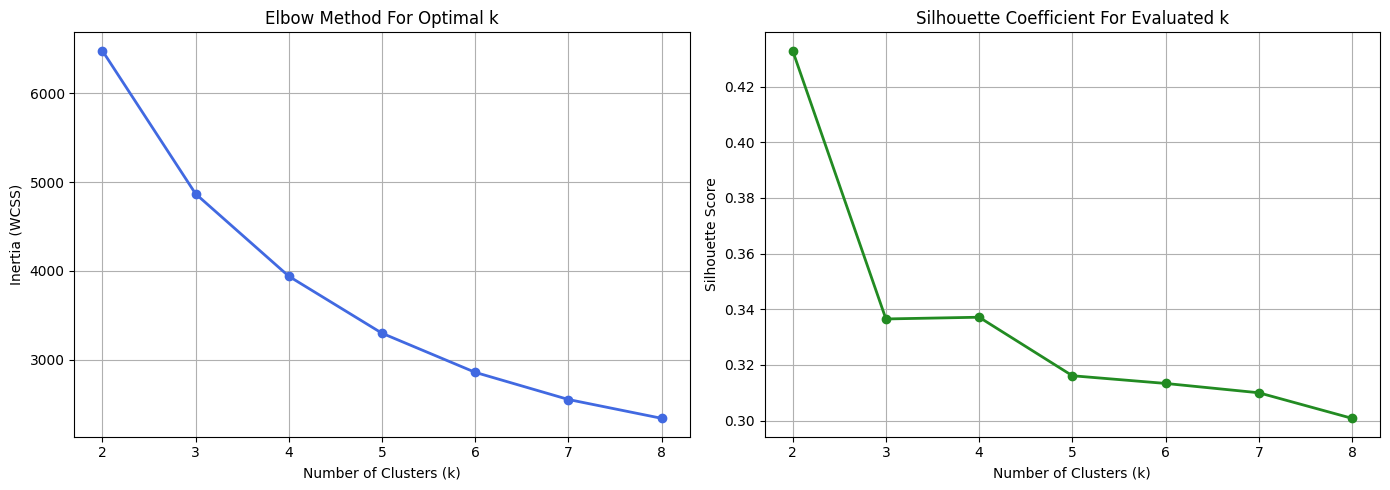

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

K-Means (k=4) Silhouette Score: 0.3371
K-Means (k=4) Davies-Bouldin Index: 1.0101


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
print("\n--- Running K-Means Diagnostics ---")
inertia = []
silhouette_avg = []
k_range = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(rfm_scaled)
    inertia.append(km.inertia_)
    silhouette_avg.append(silhouette_score(rfm_scaled, labels))

# Plot 1: Elbow Method and Silhouette Analysis Side-by-Side
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].plot(k_range, inertia, marker='o', color='royalblue', linewidth=2)
ax[0].set_title('Elbow Method For Optimal k')
ax[0].set_xlabel('Number of Clusters (k)')
ax[0].set_ylabel('Inertia (WCSS)')
ax[0].grid(True)

ax[1].plot(k_range, silhouette_avg, marker='o', color='forestgreen', linewidth=2)
ax[1].set_title('Silhouette Coefficient For Evaluated k')
ax[1].set_xlabel('Number of Clusters (k)')
ax[1].set_ylabel('Silhouette Score')
ax[1].grid(True)
plt.tight_layout()
plt.show()

# Fit Optimal K-Means (Standard configuration for Online Retail is k=4 clusters)
optimal_k = 4
kmeans_model = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
rfm['KMeans_Cluster'] = kmeans_model.fit_predict(rfm_scaled)
km_sil = silhouette_score(rfm_scaled, rfm['KMeans_Cluster'])
km_db = davies_bouldin_score(rfm_scaled, rfm['KMeans_Cluster'])
print(f"K-Means (k={optimal_k}) Silhouette Score: {km_sil:.4f}")
print(f"K-Means (k={optimal_k}) Davies-Bouldin Index: {km_db:.4f}")

In [ ]:
print("\n--- Running DBSCAN Clustering ---")
dbscan_model = DBSCAN(eps=0.4, min_samples=5) # Adjusted eps for high-density scaled RFM space
rfm['DBSCAN_Cluster'] = dbscan_model.fit_predict(rfm_scaled)
db_labels = rfm['DBSCAN_Cluster']
n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise_db = list(db_labels).count(-1)
print(f"DBSCAN Detected Clusters: {n_clusters_db}")
print(f"DBSCAN Detected Outliers/Noise Points: {n_noise_db}")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag


--- Running DBSCAN Clustering ---
DBSCAN Detected Clusters: 7
DBSCAN Detected Outliers/Noise Points: 101


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

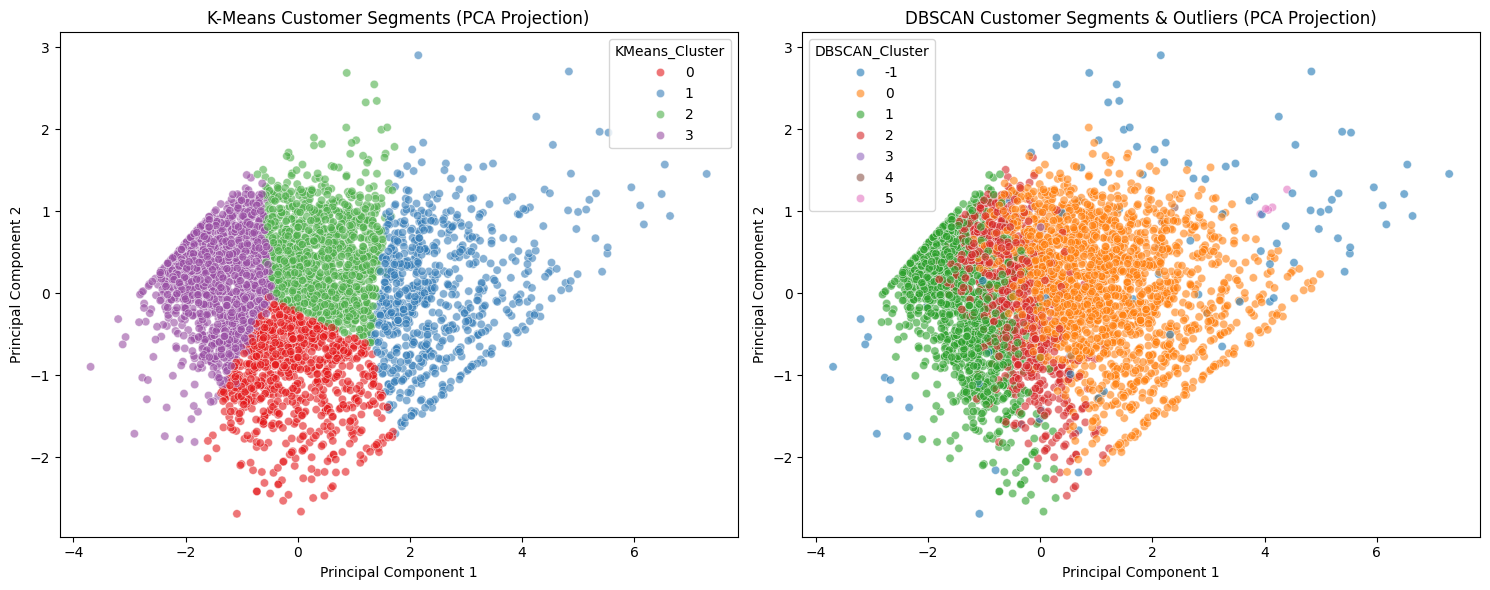

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
pca = PCA(n_components=2)
rfm_pca = pca.fit_transform(rfm_scaled)

# Plot 2: Cluster Visualizations Scatterplots
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
sns.scatterplot(x=rfm_pca[:, 0], y=rfm_pca[:, 1], hue=rfm['KMeans_Cluster'], palette='Set1', alpha=0.6)
plt.title('K-Means Customer Segments (PCA Projection)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

plt.subplot(1, 2, 2)
sns.scatterplot(x=rfm_pca[:, 0], y=rfm_pca[:, 1], hue=rfm['DBSCAN_Cluster'], palette='tab10', alpha=0.6)
plt.title('DBSCAN Customer Segments & Outliers (PCA Projection)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.tight_layout()
plt.show()

In [ ]:
print("\n--- Preparing Association Rule Mining (Apriori) ---")
# Focus on transactions with multiple items to locate item dependencies efficiently
tx_counts = df.groupby('InvoiceNo')['StockCode'].count()
mult_item_tx = tx_counts[tx_counts > 1].index
df_filtered = df[df['InvoiceNo'].isin(mult_item_tx)]

# Create the pivot transaction matrix
basket = (df_filtered.groupby(['InvoiceNo', 'Description'])['Quantity']
          .sum().unstack().reset_index().fillna(0)
          .set_index('InvoiceNo'))

# Convert item quantities to binary presence indicator matrices (0 or 1)
basket_sets = basket.map(lambda x: 1 if x > 0 else 0)

# Run Apriori
frequent_itemsets = apriori(basket_sets, min_support=0.02, use_colnames=True)
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1)
rules = rules.sort_values(by='lift', ascending=False)

print("\n--- Top 10 Association Rules Extracted ---")
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10))

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag


--- Preparing Association Rule Mining (Apriori) ---


Streaming output truncated to the last 5000 lines.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replac


--- Top 10 Association Rules Extracted ---
                                          antecedents  \
91  (ROSES REGENCY TEACUP AND SAUCER , GREEN REGEN...   
94                   (PINK REGENCY TEACUP AND SAUCER)   
95                  (GREEN REGENCY TEACUP AND SAUCER)   
90  (ROSES REGENCY TEACUP AND SAUCER , PINK REGENC...   
11                  (GREEN REGENCY TEACUP AND SAUCER)   
10                   (PINK REGENCY TEACUP AND SAUCER)   
93                 (ROSES REGENCY TEACUP AND SAUCER )   
92  (PINK REGENCY TEACUP AND SAUCER, GREEN REGENCY...   
82                 (ROSES REGENCY TEACUP AND SAUCER )   
83                   (PINK REGENCY TEACUP AND SAUCER)   

                                          consequents   support  confidence  \
91                   (PINK REGENCY TEACUP AND SAUCER)  0.022756    0.720887   
94  (ROSES REGENCY TEACUP AND SAUCER , GREEN REGEN...  0.022756    0.707804   
95  (ROSES REGENCY TEACUP AND SAUCER , PINK REGENC...  0.022756    0.564399   
90          

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

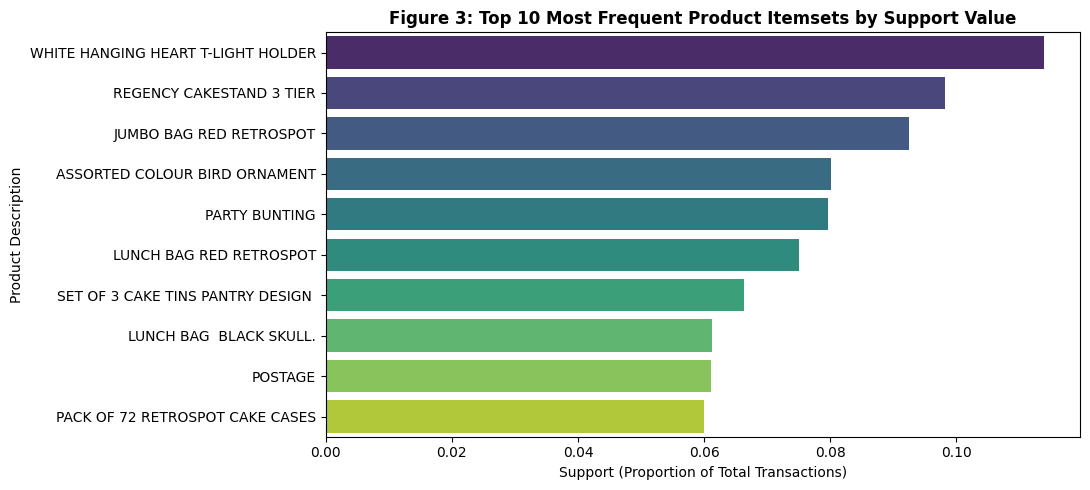

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

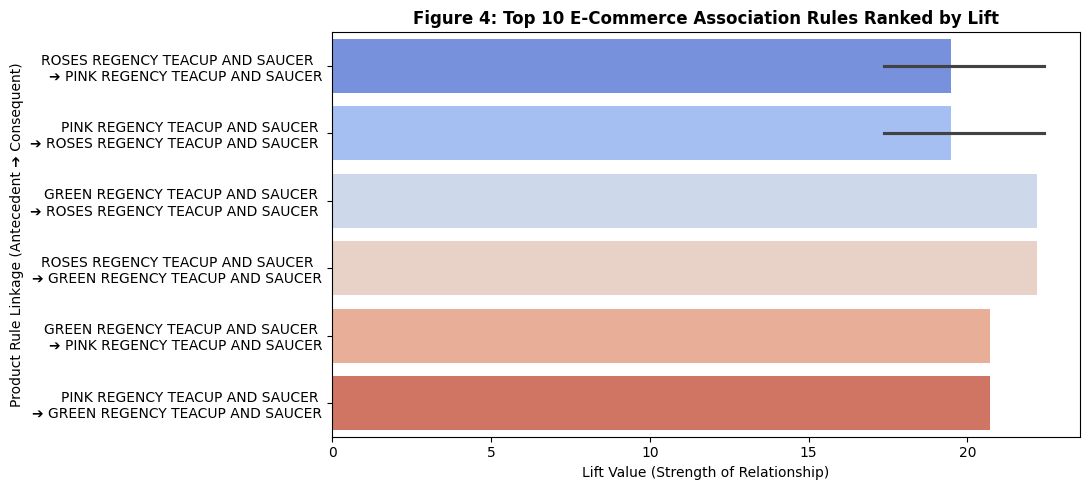

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
# 8. VISUALIZING THE TOP 10 MARKET BASKET INSIGHTS

# Graph A: Top 10 Most Frequent Items (Pruned by Support)
plt.figure(figsize=(11, 5))
frequent_itemsets['item_name'] = frequent_itemsets['itemsets'].apply(lambda x: ', '.join(list(x)))
top_10_items = frequent_itemsets.sort_values(by='support', ascending=False).head(10)

sns.barplot(x='support', y='item_name', data=top_10_items, palette='viridis')
plt.title('Figure 3: Top 10 Most Frequent Product Itemsets by Support Value', fontsize=12, fontweight='bold')
plt.xlabel('Support (Proportion of Total Transactions)')
plt.ylabel('Product Description')
plt.tight_layout()
plt.show()

# Graph B: Top 10 Association Rules Ranked by Predictive Strength (Lift)
plt.figure(figsize=(11, 5))
top_10_rules = rules.head(10).copy()
# Clean up antecedent and consequent text format for chart labeling
top_10_rules['rule_label'] = (top_10_rules['antecedents'].apply(lambda x: list(x)[0]) +
                              ' \n➔ ' +
                              top_10_rules['consequents'].apply(lambda x: list(x)[0]))

sns.barplot(x='lift', y='rule_label', data=top_10_rules, palette='coolwarm')
plt.title('Figure 4: Top 10 E-Commerce Association Rules Ranked by Lift', fontsize=12, fontweight='bold')
plt.xlabel('Lift Value (Strength of Relationship)')
plt.ylabel('Product Rule Linkage (Antecedent ➔ Consequent)')
plt.tight_layout()
plt.show()

In [ ]:
print("\nK-Means Cluster Summary")
print(rfm.groupby('KMeans_Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean'
}))

print("\nK-Means Cluster Counts")
print(rfm['KMeans_Cluster'].value_counts().sort_index())

print("\nDBSCAN Cluster Summary")
print(rfm.groupby('DBSCAN_Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean'
}))

print("\nDBSCAN Cluster Counts")
print(rfm['DBSCAN_Cluster'].value_counts().sort_index())

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag


K-Means Cluster Summary
                   Recency  Frequency     Monetary
KMeans_Cluster                                    
0                18.124253   2.148148   551.819534
1                12.131285  13.713687  8074.266872
2                71.084399   4.083546  1802.829005
3               182.496898   1.318238   343.450032

K-Means Cluster Counts
KMeans_Cluster
0     837
1     716
2    1173
3    1612
Name: count, dtype: int64

DBSCAN Cluster Summary
                   Recency  Frequency      Monetary
DBSCAN_Cluster                                     
-1               69.683168  24.029703  29061.796535
 0               43.937630   6.642412   2476.809757
 1              157.152071   1.000000    343.788052
 2               94.014493   2.000000    663.230231
 3              103.000000   1.000000   4390.982500
 4               20.666667   5.666667  15546.696667
 5                9.200000  35.000000  18205.206000

DBSCAN Cluster Counts
DBSCAN_Cluster
-1     101
 0    1924
 1    1473
 

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
print(f"K-Means (k={optimal_k}) Silhouette Score: {km_sil:.4f}")
print(f"K-Means (k={optimal_k}) Davies-Bouldin Index: {km_db:.4f}")
print(f"DBSCAN Detected Clusters: {n_clusters_db}")
print(f"DBSCAN Detected Outliers/Noise Points: {n_noise_db}")

K-Means (k=4) Silhouette Score: 0.3371
K-Means (k=4) Davies-Bouldin Index: 1.0101
DBSCAN Detected Clusters: 7
DBSCAN Detected Outliers/Noise Points: 101


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag